In [101]:
import numpy as np
import matplotlib.pyplot as plt
import freud


class PointProcess:
    def __init__(self, L=10, lambda_intensity=1.0, name=""):
        self.L = L
        self.lambda_intensity = lambda_intensity
        self.positions = None  # liste de réalisations
        self.k = None
        self.S_k = None
        self.name = name

    # =========================
    # Sampling multi-réalisations
    # =========================
    def sample(self, kind="hpp", n_samples=1):
        self.positions = []

        for _ in range(n_samples):
            if kind == "hpp":
                self.box = freud.box.Box.cube(self.L)
                N = np.random.poisson(self.lambda_intensity * self.L**3)
                pts = np.column_stack((
                    np.random.uniform(0, self.L, size=N),
                    np.random.uniform(0, self.L, size=N),
                    np.random.uniform(0, self.L, size=N)
                ))

            elif kind == "ginibre":
                self.box = freud.box.Box.cube(self.L)
                self.box.Lz = self.L/(100_000)
                N = int(self.lambda_intensity * self.L**2)
                M = self.sample_matrix(N)
                pts = self.eigval_points(M)

                mask = (np.max(pts**2, axis=1) <= 0.5)
                pts = pts[mask]

                pts = np.column_stack((
                    (pts[:, 0] + 0.5) * self.L,
                    (pts[:, 1] + 0.5) * self.L,
                    (pts[:, 0] + 0.5) * 0

                ))
            else:
                raise ValueError("Unknown process type")

            self.positions.append(pts)

    # =========================
    # Ginibre helpers
    # =========================
    @staticmethod
    def sample_matrix(N):
        re = np.random.normal(size=(N, N))
        im = np.random.normal(size=(N, N))
        M = re + 1j * im
        return M / np.sqrt(2 * N)

    @staticmethod
    def eigval_points(M):
        ev = np.linalg.eigvals(M)
        points = np.zeros((len(ev), 2))
        points[:, 0], points[:, 1] = ev.real, ev.imag
        return points

    # =========================
    # Structure factor (moyenne)
    # =========================
    def compute_structure_factor(self, method="debye", **kwargs):
        if self.positions is None:
            raise RuntimeError("Sample points first")

        if method == "debye":
                sf = freud.diffraction.StaticStructureFactorDebye(**kwargs)

        elif method == "direct":
            kwargs_local = kwargs.copy()
            if "num_k_values" in kwargs_local:
                kwargs_local["bins"] = kwargs_local.pop("num_k_values")
            sf = freud.diffraction.StaticStructureFactorDirect(**kwargs_local)

        else:
            raise ValueError("Unknown method")

        for pts in self.positions:
            sf.compute((self.box, pts), reset=False)

        self.k = sf.bin_centers if method == "direct" else sf.k_values
        self.S_k = sf.S_k

    # =========================
    # Plot points (tous les samples)
    # =========================
    def plot_points(self):
        if self.positions is None:
            raise RuntimeError("No points to plot")

        plt.figure(figsize=(5, 5))

        for pts in self.positions:
            plt.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.4)

        plt.xlim(0, self.L)
        plt.ylim(0, self.L)
        plt.gca().set_aspect('equal')
        plt.title(self.name)
        plt.show()

    # =========================
    # Plot S(k)
    # =========================
    def plot_structure_factor(self):
        if self.S_k is None:
            raise RuntimeError("Compute structure factor first")

        plt.figure()
        plt.scatter(self.k, self.S_k)
        plt.yticks([0, 1, 3])
        plt.xlabel("k")
        plt.ylabel("S(k)")
        plt.title("Structure Factor")
        plt.show()

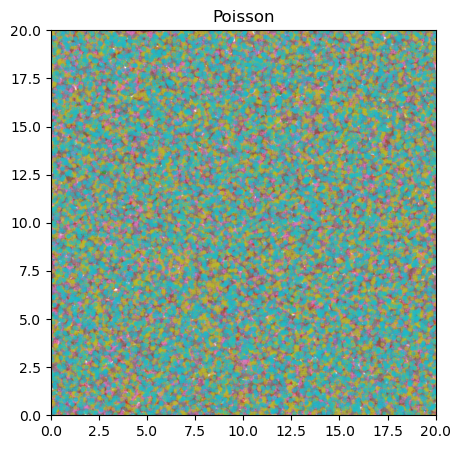

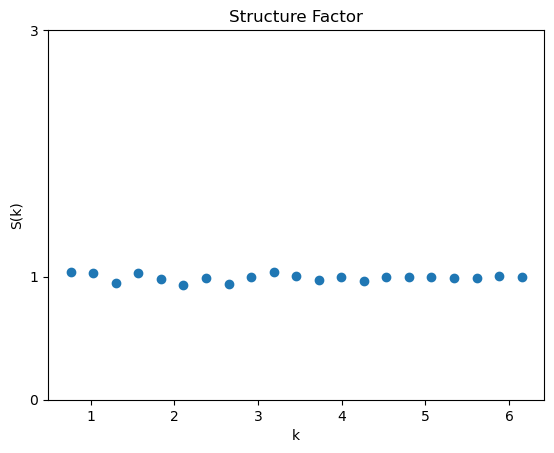

In [102]:
# =========================
# Exemple d'utilisation
# =========================

L = 20
k0 = 2 * np.pi / L

n_min = 2
n_max = 20

k_min = n_min * k0
k_max = n_max * k0

pp = PointProcess(L=L, lambda_intensity=1.0, name = "Poisson")

pp.sample(kind="hpp", n_samples=10)

pp.plot_points()

pp.compute_structure_factor(
    method="direct",
    num_k_values=21,
    k_min=k_min,
    k_max=k_max
)

pp.plot_structure_factor()

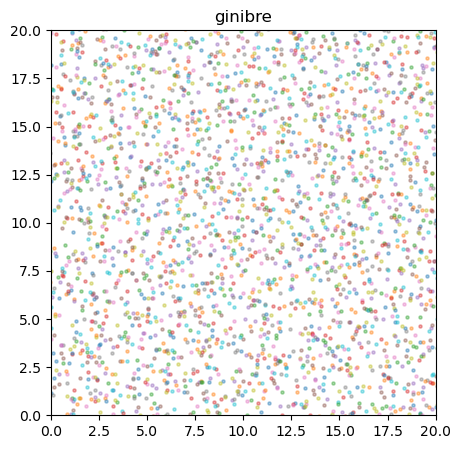

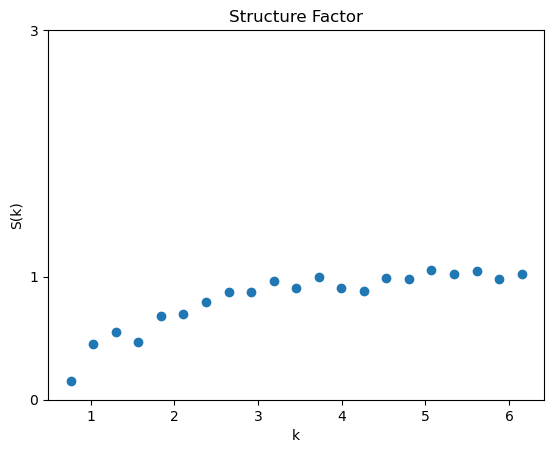

In [103]:
pp = PointProcess(L=L, lambda_intensity=1.0, name="ginibre")
pp.sample(kind="ginibre", n_samples= 20)
pp.plot_points()
pp.compute_structure_factor(method="direct", num_k_values=21, k_min = k_min, k_max=k_max)
pp.plot_structure_factor()